In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/laptop_processed.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1275, 28)


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,...,Hybrid_GB,Total_Storage_GB,Storage_Type,Resolution_Width,Resolution_Height,Touchscreen,IPS,CPU_Family,GPU_Family,OS_Family
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,...,0.0,128.0,SSD,2560,1600,0,1,Core i5,Other,macOS
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,...,0.0,128.0,Flash,1440,900,0,0,Core i5,Intel HD,macOS
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,...,0.0,256.0,SSD,1920,1080,0,0,Core i5,Intel HD,No OS
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,...,0.0,512.0,SSD,2880,1800,0,1,Core i7,AMD Radeon,macOS
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,...,0.0,256.0,SSD,2560,1600,0,1,Core i5,Other,macOS


In [3]:
X = df.drop("Price (Euro)", axis=1)
y = df["Price (Euro)"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1275, 27)
y shape: (1275,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1020, 27)
Testing data: (255, 27)


In [5]:
preprocessor = joblib.load("../models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (1020, 80)
Processed testing data: (255, 80)


In [6]:
baseline_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(
    X_train_processed,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test_processed
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline Random Forest")
print("----------------------")
print(f"MAE  : €{baseline_mae:.2f}")
print(f"RMSE : €{baseline_rmse:.2f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Random Forest
----------------------
MAE  : €180.12
RMSE : €270.72
R²   : 0.8523


In [7]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print("Number of parameter combinations:")

total_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_split"])
    * len(param_grid["min_samples_leaf"])
)

print(total_combinations)

Number of parameter combinations:
24


In [8]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [9]:
# ============================================
# MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    
    "MAE": [
        180.12,
        179.98
    ],
    
    "RMSE": [
        270.72,
        268.95
    ],
    
    "R2 Score": [
        0.8523,
        0.8543
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Baseline Random Forest,180.12,270.72,0.8523
1,Tuned Random Forest,179.98,268.95,0.8543


In [10]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])
print("R² Score:", best_model["R2 Score"])

Best Model: Tuned Random Forest
MAE: 179.98
RMSE: 268.95
R² Score: 0.8543


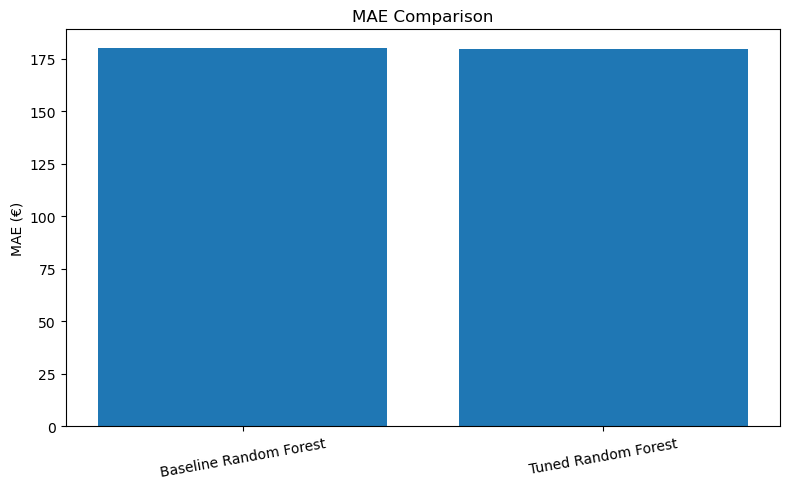

In [11]:
import matplotlib.pyplot as plt

models = [
    "Baseline Random Forest",
    "Tuned Random Forest"
]

mae_values = [180.12, 179.98]
rmse_values = [270.72, 268.95]
r2_values = [0.8523, 0.8543]


# ============================================
# MAE COMPARISON
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(models, mae_values)

plt.ylabel("MAE (€)")
plt.title("MAE Comparison")

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

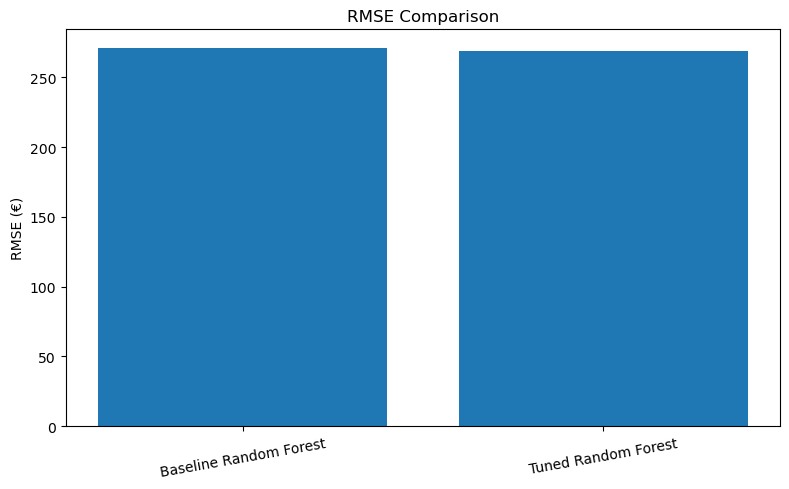

In [12]:
# ============================================
# RMSE COMPARISON
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(models, rmse_values)

plt.ylabel("RMSE (€)")
plt.title("RMSE Comparison")

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

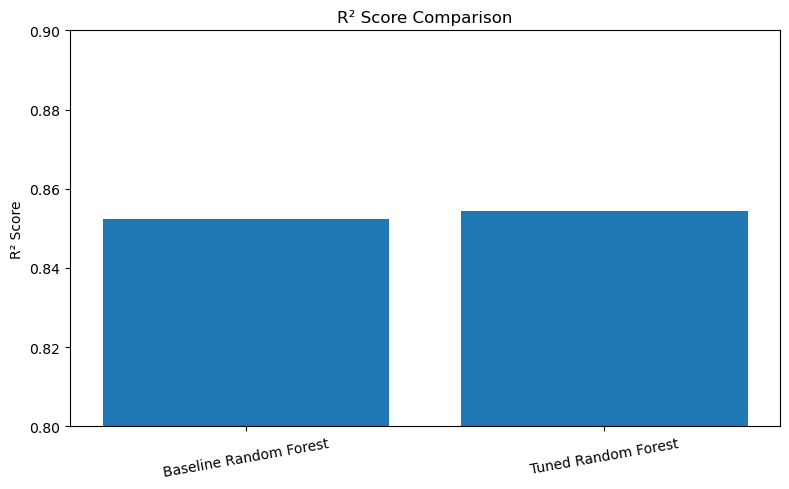

In [13]:
# ============================================
# R² COMPARISON
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.ylim(0.8, 0.9)

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

In [15]:
import joblib
import os

# Best model obtained from GridSearchCV
tuned_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Model:")
print(tuned_model)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Model:
RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)


In [16]:
import os
import joblib

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save best tuned model
joblib.dump(
    tuned_model,
    "../models/final_laptop_price_model.pkl"
)

print("✅ Final tuned model saved successfully!")

✅ Final tuned model saved successfully!


In [17]:
import os

model_path = "../models/final_laptop_price_model.pkl"

print("File exists:", os.path.exists(model_path))
print("Model path:", model_path)

File exists: True
Model path: ../models/final_laptop_price_model.pkl


In [18]:
loaded_model = joblib.load(
    "../models/final_laptop_price_model.pkl"
)

print("✅ Model loaded successfully!")
print(type(loaded_model))

✅ Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [19]:
# ============================================
# TUNED MODEL EVALUATION
# ============================================

tuned_predictions = tuned_model.predict(X_test_processed)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned Random Forest")
print("-------------------")
print(f"MAE  : €{tuned_mae:.2f}")
print(f"RMSE : €{tuned_rmse:.2f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned Random Forest
-------------------
MAE  : €178.41
RMSE : €267.82
R²   : 0.8555


In [20]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "MAE (€)": [
        baseline_mae,
        tuned_mae
    ],
    "RMSE (€)": [
        baseline_rmse,
        tuned_rmse
    ],
    "R²": [
        baseline_r2,
        tuned_r2
    ]
})

final_comparison

,Model,MAE (€),RMSE (€),R²
0,Baseline Random Forest,180.123240,270.720059,0.852340
1,Tuned Random Forest,178.410235,267.817761,0.855489


In [21]:
mae_improvement = baseline_mae - tuned_mae
rmse_improvement = baseline_rmse - tuned_rmse
r2_improvement = tuned_r2 - baseline_r2

print(f"MAE improvement  : €{mae_improvement:.2f}")
print(f"RMSE improvement : €{rmse_improvement:.2f}")
print(f"R² improvement   : {r2_improvement:.4f}")

MAE improvement  : €1.71
RMSE improvement : €2.90
R² improvement   : 0.0031


## Day 8 - Hyperparameter Tuning Conclusion

Hyperparameter tuning was performed on the Random Forest Regression model
using GridSearchCV.

The tuned model showed a small but consistent improvement over the
baseline Random Forest model.

### Improvement

- MAE improved by €1.71
- RMSE improved by €2.90
- R² improved by 0.0031

Therefore, the tuned Random Forest model was selected as the final model
for the laptop price prediction project.

Although the improvement is relatively small, hyperparameter tuning helped
reduce prediction error and slightly improved the model's overall
performance.